# ARISTA: growth during brain regeneration

Generate the four intermediate populations between the five measured ARISTA
stages, evaluate growth, and draw the spatial maps in Supplementary Fig. S20.
The notebook calculates the growth values from the model before drawing them.

## Prepare the data and model

Follow [installation](../../installation.md), then extract `arista_model.zip`
and `arista_analysis_data.zip` from the [data page](../../data_checkpoints.md).
Set `PROJECT_DIR` below to the folder containing the extracted `data/` directory.
To fit a model from counts, start with [Train a model](../../training.md).

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.patches import Ellipse
import CytoBridge as cb
from CytoBridge.workflow import load_workflow_config

PROJECT_DIR = Path(os.environ.get("CYTOBRIDGE_PROJECT_DIR", ".")).resolve()
DATA_DIR = PROJECT_DIR / "data" / "arista"
OUTPUT_DIR = PROJECT_DIR / "outputs" / "arista_growth"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = "cuda"
config, _ = load_workflow_config(DATA_DIR / "workflow.json")
fields = config["dataset"]
settings = config["downstream"]
observed_times = settings["observed"]
intermediate_times = settings["interpolated"]
times = sorted(observed_times + intermediate_times)
plt.rcParams.update({
    "font.family": "Arial", "font.size": 9, "text.color": "black",
    "axes.labelcolor": "black", "xtick.color": "black", "ytick.color": "black",
    "pdf.fonttype": 42, "svg.fonttype": "none",
})

## Load the observed states and model

The aligned file contains the coordinates and 50 PCA features used for
training. The five model times, 0–4, correspond to 2, 5, 10, 15, and 20 days
after injury. The model and classifier use these same features.

In [2]:
reference = ad.read_h5ad(DATA_DIR / "aligned.h5ad")
frame, time_key = cb.tl.adata_to_aligned_dataframe(
    reference, time_key=fields["time_key"], obsm_key=fields["obsm_key"],
    spatial_key=fields["spatial_key"], concat_spatial=True,
    annotation_key=fields["annotation_key"],
)
features = cb.tl.infer_feature_columns(frame, annotation_column=fields["annotation_key"])
loaded = cb.tl.load_dynamical_model_from_dir(
    DATA_DIR / "model", dim=len(features), device=DEVICE,
    edge_predictor_path=DATA_DIR / "edge_classifier" / "arista_edge_model.pt",
)
runtime = cb.tl.build_dynamical_runtime(loaded)
frame.groupby("samples").size().rename("Observed cells")

samples
0.0     7668
1.0     8106
2.0     9436
3.0     9673
4.0    11316
Name: Observed cells, dtype: int64

## Generate the intermediate populations

The simulation starts with the 7,668 cells at t=0 and includes growth-dependent
division and removal. It continues across the full interval without restarting
at later observations. The returned `adata_dict` retains measured cells at
observed times and uses simulated cells at the four intermediate times.

The pretrained classifier assigns cell types to generated cells. Its spatial
smoothing uses 10 neighbours, as in the paper. Coordinates are not warped
after simulation.

In [3]:
result = cb.tl.run_interpolation_workflow(
    df=frame, dim=len(features), annotation_key=fields["annotation_key"],
    runtime=runtime, device=DEVICE, output_dir=str(OUTPUT_DIR),
    requested_plot_points=times, interp_time_points=intermediate_times,
    max_observed_timepoints=5,
    classifier_cache_path=str(DATA_DIR / "classifier_cache" / "classifier_resmlp_8e447c8c5a7ba154.pt"),
    classifier_adata=reference, classifier_time_key=time_key,
    classifier_obsm_key=fields["obsm_key"], classifier_spatial_key=fields["spatial_key"],
    classifier_concat_spatial=True, classifier_epochs=500,
    classifier_hidden_size=128, classifier_lr=0.001,
    classifier_best_metric="bacc", classifier_strict_stratification=True,
    classifier_knn_neighbors=10,
    sde_n_samples=7668, skip_nonsplit_sde=True,
    sde_dt=0.05, split_sde_dt=0.01, split_sigma_scalar=0.03,
    split_daughter_noise_std=0.0, split_growth_alpha=1.0,
    split_interaction_m=1024, split_resample_dt=None, split_max_particles=None,
    split_sde_piecewise=False,
    spatial_warp_to_observed_piecewise=False, spatial_warp_visualization_only=True,
    random_seed=42,
)

## Calculate growth

Evaluate the growth network on every cell in each measured or generated
population. Save both the model states and the resulting table, so plotting
can be repeated without running the simulation again.

In [4]:
population_dir = OUTPUT_DIR / "populations"
population_dir.mkdir(exist_ok=True)
for time, key in zip(result.ts_points, result.time_keys):
    result.adata_dict[key].write_h5ad(population_dir / f"time_{time:g}.h5ad")
growth = cb.tl.evaluate_growth_by_timepoint(
    result.adata_dict, loaded.model, time_points=result.ts_points,
    annotation_key=fields["annotation_key"], device=DEVICE,
)
growth.to_csv(OUTPUT_DIR / "growth_by_cell.csv", index=False)
growth.groupby("time")["growth"].agg(["count", "median"])

,count,median
time,,
0.0,7668,0.008724
0.5,7775,0.042139
1.0,8106,0.065417
1.5,8545,0.134228
2.0,9436,0.139348
2.5,9598,0.033764
3.0,9673,0.001539
3.5,9962,0.131848
4.0,11316,0.288400


## Select cells for display

S20 displays a random sample of 2,500 cells per stage. Sampling affects only
the plot. The calculation and `growth_by_cell.csv` retain all cells.
The 5th and 95th percentiles of each displayed sample set that panel's colour
limits. The same seed and sampling order are used here.

In [5]:
rng = np.random.default_rng(42)
samples = []
for time, cells in growth.groupby("time", sort=True):
    cells = cells.sort_values("cell_index").reset_index(drop=True)
    indices = np.sort(rng.choice(len(cells), size=min(2500, len(cells)), replace=False))
    samples.append(cells.iloc[indices])
display_cells = pd.concat(samples, ignore_index=True)
display_cells.to_csv(OUTPUT_DIR / "growth_display_sample.csv", index=False)
colour_limits = display_cells.groupby("time")["growth"].quantile([0.05, 0.95]).unstack()
colour_limits.columns = ["5th percentile", "95th percentile"]
colour_limits.to_csv(OUTPUT_DIR / "growth_colour_limits.csv")
colour_limits

,5th percentile,95th percentile
time,,
0.0,-0.104973,0.142237
0.5,-0.065014,0.190137
1.0,-0.045092,0.205369
1.5,-0.002483,0.301386
2.0,0.001653,0.286839
2.5,-0.130918,0.215389
3.0,-0.128284,0.191662
3.5,-0.063012,0.338533
4.0,0.130034,0.469960


## Draw the growth maps — S20

Each panel uses the sampled coordinates and growth values above. The dashed
ellipse marks the anatomical location of the injury, as in S20.

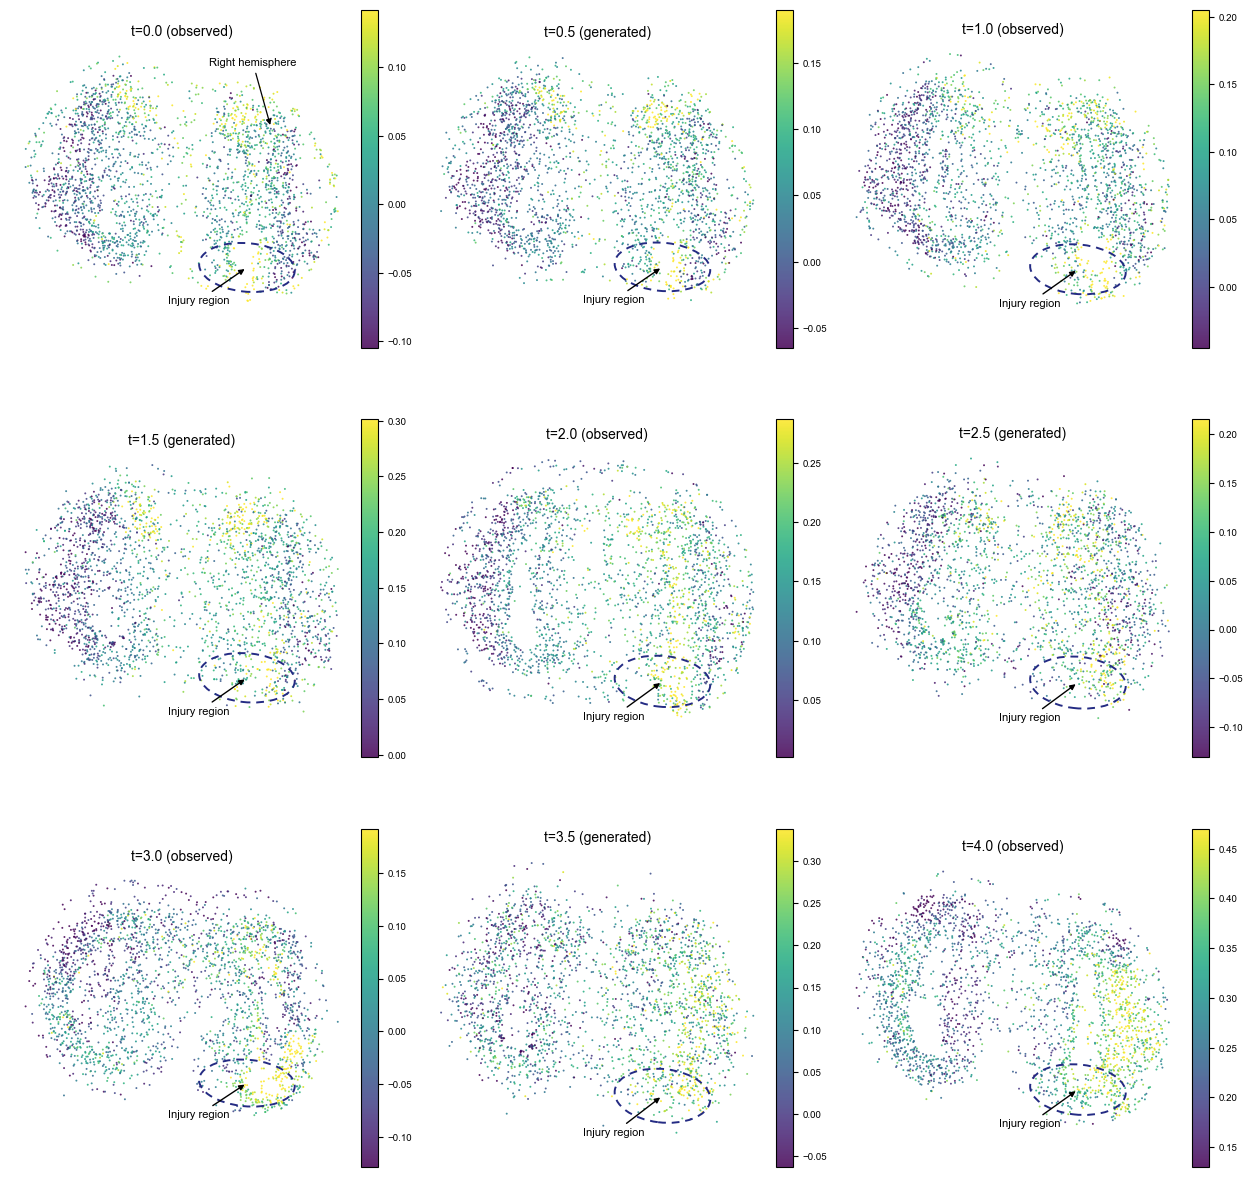

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(12.6, 12.6))
for ax, (time, cells) in zip(axes.flat, display_cells.groupby("time", sort=True)):
    low, high = colour_limits.loc[time]
    if low == high:
        high = np.nextafter(high, np.inf)
    scatter = ax.scatter(cells["x"], cells["y"], c=cells["growth"],
                         cmap="viridis", norm=Normalize(low, high, clip=True),
                         s=2, alpha=0.85, linewidths=0)
    source = "observed" if time in observed_times else "generated"
    ax.set_title(f"t={time:.1f} ({source})", fontsize=10)
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.add_patch(Ellipse((0.69, 0.17), width=0.28, height=0.18, angle=-8,
                        transform=ax.transAxes, fill=False, edgecolor="#242b83",
                        linewidth=1.4, linestyle=(0, (4, 3))))
    ax.annotate("Injury region", xy=(0.69, 0.17), xytext=(0.46, 0.035),
                xycoords="axes fraction", textcoords="axes fraction",
                fontsize=8, color="black", fontweight="bold",
                arrowprops={"arrowstyle": "-|>", "color": "black", "lw": 1})
    if time == 0:
        ax.annotate("Right hemisphere", xy=(0.76, 0.69), xytext=(0.58, 0.92),
                    xycoords="axes fraction", textcoords="axes fraction", fontsize=8,
                    arrowprops={"arrowstyle": "-|>", "color": "black", "lw": 0.9})
    colourbar = fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.02)
    colourbar.ax.tick_params(labelsize=7)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "growth_maps_S20.pdf", bbox_inches="tight")
plt.show()

## Other ARISTA figures

The [S19–S24 page](../paper_figures/arista_figures.ipynb) collects the paper's
spatial, lineage, gene-program, and ligand–receptor figures. These use their
own saved analysis results, not the growth table from this notebook.
[S25](../paper_figures/arista_local_domains.ipynb) examines local signalling
domains. Growth-based population counts and fixed-particle lineage fractions
are separate analyses.